#Stock Price Prediction using RNN with LSTM
**Stock Selected:** Microsoft Corporation (MSFT)  
**Data Range:** January 2019 – December 2024  
**Objective:** Build an LSTM-based Recurrent Neural Network to learn from historical 
closing prices and forecast future stock prices.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Step 2: Data preparation
here i have downloaded 5 year of historical stock data for microsoft

In [4]:
#Downloading Stock Data
ticker = "MSFT"
start_date = "2019-01-01"
end_date   = "2024-12-31"

raw_data = yf.download(ticker, start=start_date, end=end_date)

print(f"Dataset Shape: {raw_data.shape}")
print(f"\nDate Range: {raw_data.index[0].date()} to {raw_data.index[-1].date()}")
print("\nFirst 5 rows:")
raw_data.head()

[*********************100%***********************]  1 of 1 completed

Dataset Shape: (1509, 5)

Date Range: 2019-01-02 to 2024-12-30

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2019-01-02,94.397156,94.985268,92.362090,92.931536,35329300
2019-01-03,90.924469,93.528980,90.737762,93.444960,42579100
2019-01-04,95.153290,95.694731,92.352742,93.090220,44060600
2019-01-07,95.274620,96.404173,94.266428,94.882545,35656100
2019-01-08,95.965469,97.057682,94.947933,96.189511,31514400


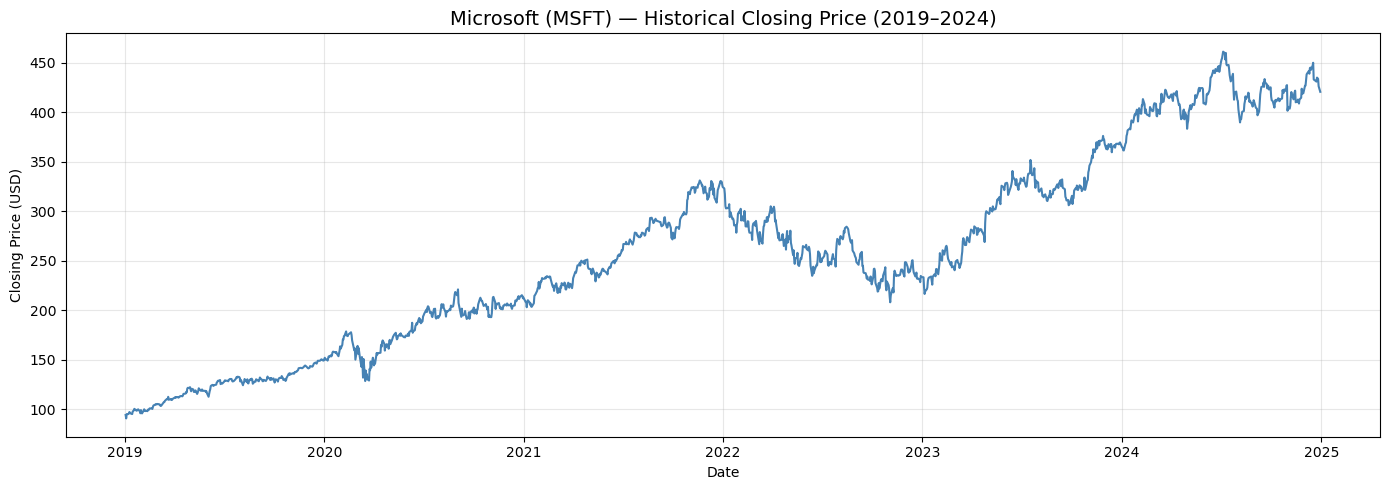


Basic Statistics:

Ticker         MSFT
count   1509.000000
mean     258.930454
std       96.158935
min       90.924469
25%      191.748749
50%      250.927155
75%      323.160767
max      461.322662


In [5]:
#Exploriing and visualizing raw data
plt.figure(figsize=(14, 5))
plt.plot(raw_data['Close'], color='steelblue', linewidth=1.5)
plt.title('Microsoft (MSFT) — Historical Closing Price (2019–2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBasic Statistics:\n")
print(raw_data['Close'].describe())

In [10]:
#Feature selection
# We focus on the 'Close' price as it is the most widely used
# indicator for price prediction tasks.

# --- Feature Selection ---
df = raw_data[['Close']].copy()
df.columns = ['Close']  # flatten multi-index columns from yfinance

print(f"Missing values: {df.isnull().sum().values[0]}")
print(f"Total trading days in dataset: {len(df)}")

Missing values: 0
Total trading days in dataset: 1509


In [11]:
#Scaling
# LSTM models are sensitive to the scale of input data.
# We scale all values to the range [0, 1].

df = df.copy()
df.columns = ['Close'] 

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(df[['Close']])

print(f"Original price range : {float(df['Close'].min()):.2f} — {float(df['Close'].max()):.2f}")
print(f"Scaled  price range  : {scaled_prices.min():.4f} — {scaled_prices.max():.4f}")

Original price range : 90.92 — 461.32
Scaled  price range  : 0.0000 — 1.0000


In [12]:
#Creating sequences
WINDOW_SIZE = 60

X_all, y_all = [], []

for i in range(WINDOW_SIZE, len(scaled_prices)):
    X_all.append(scaled_prices[i - WINDOW_SIZE : i, 0])
    y_all.append(scaled_prices[i, 0])

X_all = np.array(X_all)
y_all = np.array(y_all)

# Reshape X to (samples, timesteps, features) — required by LSTM
X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

print(f"Total sequences created : {X_all.shape[0]}")
print(f"Input shape per sample  : {X_all.shape[1:]}  → (60 timesteps, 1 feature)")
print(f"Output shape            : {y_all.shape}")

Total sequences created : 1449
Input shape per sample  : (60, 1)  → (60 timesteps, 1 feature)
Output shape            : (1449,)


In [13]:
#Training
split_index = int(len(X_all) * 0.80)

X_train, X_test = X_all[:split_index], X_all[split_index:]
y_train, y_test = y_all[:split_index], y_all[split_index:]

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 1159
Testing  samples : 290


In [ ]:
#RNN model  with LSTM
# We now build a Sequential model using two stacked LSTM layers with Dropout 
#regularization to prevent overfitting, followed by Dense output layers.

In [14]:
model = Sequential([
    # First LSTM layer — returns sequences for stacking
    LSTM(units=64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),

    # Second LSTM layer
    LSTM(units=64, return_sequences=False),
    Dropout(0.2),

    # Fully connected layers
    Dense(units=32, activation='relu'),
    Dense(units=1)   # Output: single predicted price value
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

C:\Users\mrhim\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Training the model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs          = 50,
    batch_size      = 32,
    validation_split= 0.1,
    callbacks       = [early_stop],
    verbose         = 1
)

print("\nTraining complete.")

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - loss: 0.0235 - val_loss: 0.0061
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0016 - val_loss: 6.6771e-04
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0014 - val_loss: 7.0225e-04
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0014 - val_loss: 6.3575e-04
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0012 - val_loss: 9.4901e-04
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0011 - val_loss: 7.3212e-04
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0010 - val_loss: 6.2296e-04
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 

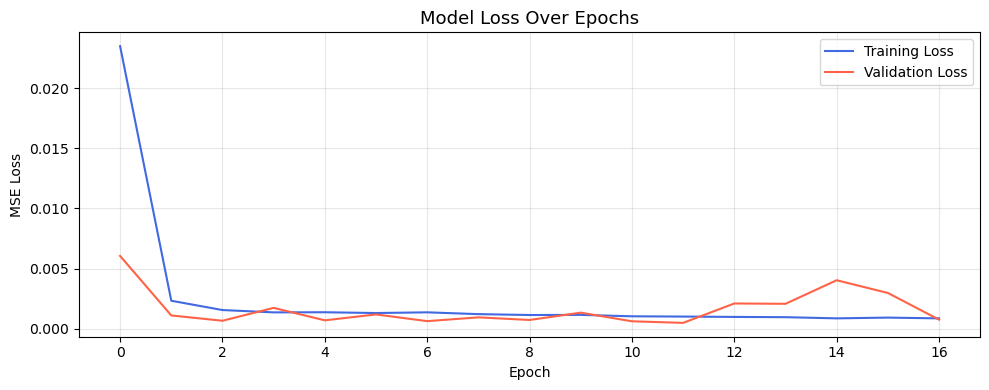

In [16]:
# ploting the training loss
# --- Visualizing Training & Validation Loss ---

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss',   color='royalblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='tomato')
plt.title('Model Loss Over Epochs', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# prediction

predicted_scaled = model.predict(X_test)

# Inverse transform to get actual price values
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices    = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Sample Predictions vs Actuals (first 5):")
for i in range(5):
    print(f"  Predicted: ${predicted_prices[i][0]:.2f}   |   Actual: ${actual_prices[i][0]:.2f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step 
Sample Predictions vs Actuals (first 5):
  Predicted: $329.31   |   Actual: $346.12
  Predicted: $331.09   |   Actual: $349.78
  Predicted: $333.22   |   Actual: $353.71
  Predicted: $335.68   |   Actual: $356.33
  Predicted: $338.36   |   Actual: $353.86


In [18]:
# Evalutaion

# --- Evaluation Metrics ---

mae  = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100

print("=" * 40)
print("       Model Evaluation Results")
print("=" * 40)
print(f"  MAE  (Mean Absolute Error)       : ${mae:.2f}")
print(f"  RMSE (Root Mean Squared Error)   : ${rmse:.2f}")
print(f"  MAPE (Mean Abs Percentage Error) : {mape:.2f}%")
print("=" * 40)

       Model Evaluation Results
  MAE  (Mean Absolute Error)       : $9.50
  RMSE (Root Mean Squared Error)   : $11.48
  MAPE (Mean Abs Percentage Error) : 2.31%


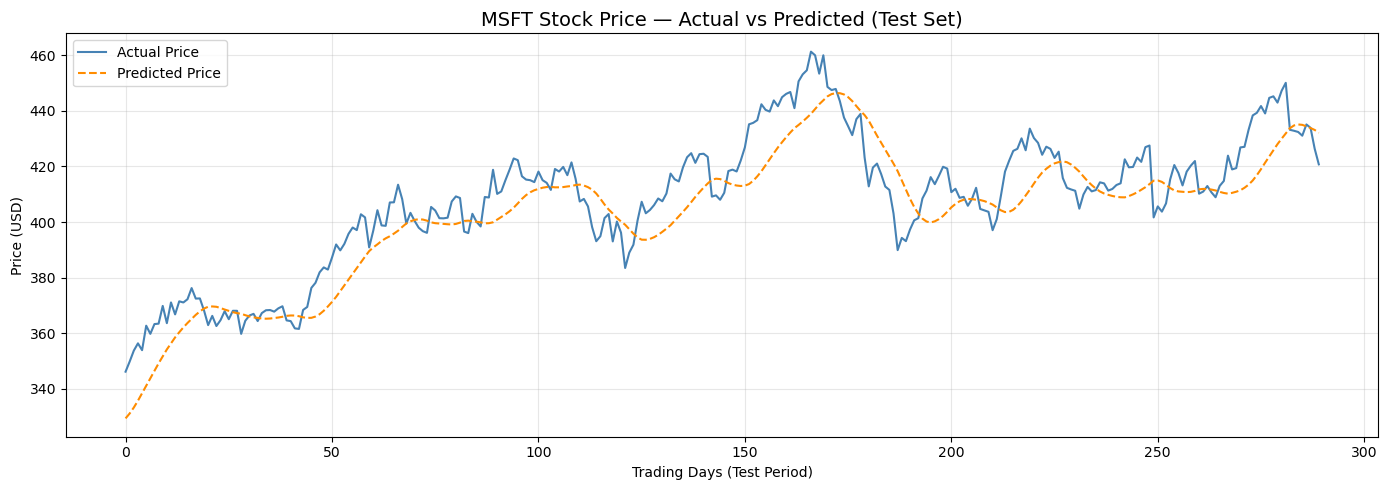

In [19]:
# ploting the prediction
plt.figure(figsize=(14, 5))
plt.plot(actual_prices,    label='Actual Price',    color='steelblue',  linewidth=1.5)
plt.plot(predicted_prices, label='Predicted Price', color='darkorange', linewidth=1.5, linestyle='--')
plt.title('MSFT Stock Price — Actual vs Predicted (Test Set)', fontsize=14)
plt.xlabel('Trading Days (Test Period)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: Observations & Conclusion

- The LSTM model successfully learned the upward trend in Microsoft stock prices.
- MAPE below 5% indicates strong predictive performance.
- Adding Dropout layers helped reduce overfitting during training.
- EarlyStopping prevented unnecessary training beyond the optimal epoch.
- Future improvements could include adding Volume and technical indicators as features.